# Credit Scoring Model using Machine Learning

This project predicts whether a loan applicant is creditworthy or at risk of default using financial and behavioral features.

The project demonstrates an end-to-end machine learning workflow including:

• Data exploration  
• Feature selection  
• Model training  
• Model evaluation  

Machine learning models used:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

## Business Problem

Financial institutions need to evaluate loan applicants carefully to reduce the risk of loan defaults.

Machine learning models can analyze financial attributes such as income, credit score, and debt levels to predict whether an applicant is likely to repay a loan.

This project builds a predictive model that classifies applicants as creditworthy or high risk.

# credit_scoring_project_ML_Model

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset

In [4]:
df = pd.read_csv("credit_dataset.csv")

df.head()

,age,annual_income,employment_years,loan_amount,loan_term_months,num_credit_lines,num_late_payments,credit_utilization,existing_debt,num_inquiries,...,credit_score,debt_to_income,creditworthy,loan_income_ratio,monthly_debt_burden,late_payment_rate,credit_score_band,high_utilization,has_late_payments,experience_income_ratio
0,25,83664,11,61258,24,4,6,19.34,0,6,...,483,0.7322,0,0.7322,0.00,1.2000,0,0,1,1.3148
1,58,56830,18,10476,36,7,8,31.49,18705,0,...,478,0.5135,0,0.1843,505.54,1.0000,0,1,1,3.1673
2,53,66615,6,34238,60,6,8,90.24,18257,6,...,349,0.7880,0,0.5140,299.30,1.1429,0,1,1,0.9007
3,42,53864,30,3074,24,5,1,79.65,19829,6,...,613,0.4252,0,0.0571,793.16,0.1667,1,1,1,5.5696
4,42,51591,25,37275,48,2,5,94.69,39062,6,...,466,1.4797,0,0.7225,797.18,1.6667,0,1,1,4.8458


In [5]:
df.shape

(1000, 22)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      1000 non-null   int64  
 1   annual_income            1000 non-null   int64  
 2   employment_years         1000 non-null   int64  
 3   loan_amount              1000 non-null   int64  
 4   loan_term_months         1000 non-null   int64  
 5   num_credit_lines         1000 non-null   int64  
 6   num_late_payments        1000 non-null   int64  
 7   credit_utilization       1000 non-null   float64
 8   existing_debt            1000 non-null   int64  
 9   num_inquiries            1000 non-null   int64  
 10  education_level          1000 non-null   int64  
 11  home_ownership           1000 non-null   int64  
 12  credit_score             1000 non-null   int64  
 13  debt_to_income           1000 non-null   float64
 14  creditworthy             

In [7]:
df.describe()

,age,annual_income,employment_years,loan_amount,loan_term_months,num_credit_lines,num_late_payments,credit_utilization,existing_debt,num_inquiries,...,credit_score,debt_to_income,creditworthy,loan_income_ratio,monthly_debt_burden,late_payment_rate,credit_score_band,high_utilization,has_late_payments,experience_income_ratio
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,45.161000,54824.754000,16.912000,40459.875000,35.952000,4.824000,4.38900,48.734070,18653.809000,3.362000,...,536.280000,1.285483,0.321000,0.875085,673.733910,0.967508,0.420000,0.68300,0.901000,3.676077
std,14.150806,19814.780281,10.002815,22955.111291,16.627272,2.614548,2.82837,28.130921,9713.278092,2.304401,...,92.689033,0.915367,0.467094,0.716330,582.476033,0.873998,0.630871,0.46554,0.298811,3.094268
min,21.000000,15000.000000,0.000000,2120.000000,12.000000,1.000000,0.00000,0.090000,0.000000,0.000000,...,312.000000,0.041000,0.000000,0.031800,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,33.000000,41269.500000,8.000000,21709.250000,24.000000,3.000000,2.00000,24.295000,11656.750000,1.000000,...,466.000000,0.707150,0.000000,0.391825,286.027500,0.333300,0.000000,0.00000,1.000000,1.457500
50%,45.000000,55068.500000,17.000000,39953.000000,36.000000,5.000000,4.00000,47.965000,18708.500000,3.000000,...,539.000000,1.073650,0.000000,0.721550,501.020000,0.777800,0.000000,1.00000,1.000000,3.124750
75%,58.000000,67714.750000,26.000000,61009.750000,48.000000,7.000000,7.00000,72.722500,25266.500000,5.000000,...,610.000000,1.556175,1.000000,1.137300,874.170000,1.333300,1.000000,1.00000,1.000000,4.942025
max,69.000000,118577.000000,34.000000,79981.000000,60.000000,9.000000,9.00000,99.970000,50412.000000,7.000000,...,752.000000,7.431700,1.000000,4.804900,3334.540000,4.500000,3.000000,1.00000,1.000000,22.666700


In [8]:
df.isnull().sum()

age                        0
annual_income              0
employment_years           0
loan_amount                0
loan_term_months           0
num_credit_lines           0
num_late_payments          0
credit_utilization         0
existing_debt              0
num_inquiries              0
education_level            0
home_ownership             0
credit_score               0
debt_to_income             0
creditworthy               0
loan_income_ratio          0
monthly_debt_burden        0
late_payment_rate          0
credit_score_band          0
high_utilization           0
has_late_payments          0
experience_income_ratio    0
dtype: int64

# Machine Learning Models 

# 1. Define Features and Target

In [4]:
X = df.drop("creditworthy", axis=1)

y = df["creditworthy"]

# 2. Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 21)
Test shape: (200, 21)


# 3. Feature Scaling

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled Training Data Shape:", X_train_scaled.shape)

print("First 5 rows of scaled data:")

print(X_train_scaled[:5])

Scaled Training Data Shape: (800, 21)
First 5 rows of scaled data:
[[-0.19806489 -1.57839209 -0.117523    0.98898799 -0.0053504   0.84677253
   0.93565475  1.64286697  1.01907013 -1.4636691  -0.1381921   1.08634671
  -1.00633383  2.78051588  2.47069945  0.16649777 -0.09101743 -0.6714653
   0.68599434  0.33333333  0.93654528]
 [-1.19016093  0.05571726  1.18968472 -0.98629238  1.42142277 -1.47315222
  -0.48334771  1.00478699 -0.75914227 -0.58458856 -1.22205171 -1.23738956
   0.61704709 -0.8325455  -0.77584109 -0.82433337  0.64059393  0.8900819
   0.68599434  0.33333333  0.44784742]
 [-0.83584092 -0.76901083  0.08358588 -0.42123779  1.42142277 -1.08649809
   0.58090413 -0.50346657  0.26271617  1.61311279 -0.1381921   1.08634671
  -0.82235066  0.02036859 -0.14319615 -0.54931141  1.22588301 -0.6714653
   0.68599434  0.33333333  0.24421545]
 [ 1.29007918  0.81900735  0.3852492   0.80829562  0.70803619 -1.47315222
  -0.83809833  0.00898476  1.24287449  0.29449198 -1.22205171 -0.07552143
   0.

# 4.Logistic Regression Model

In [7]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.835


# 5.Decision Tree Model

In [8]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.735


# 6.Random Forest Model

In [9]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.825


# 7.Gradient Boosting Model

In [10]:
gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

Gradient Boosting Accuracy: 0.825


# 8. Model Comparison Visualization

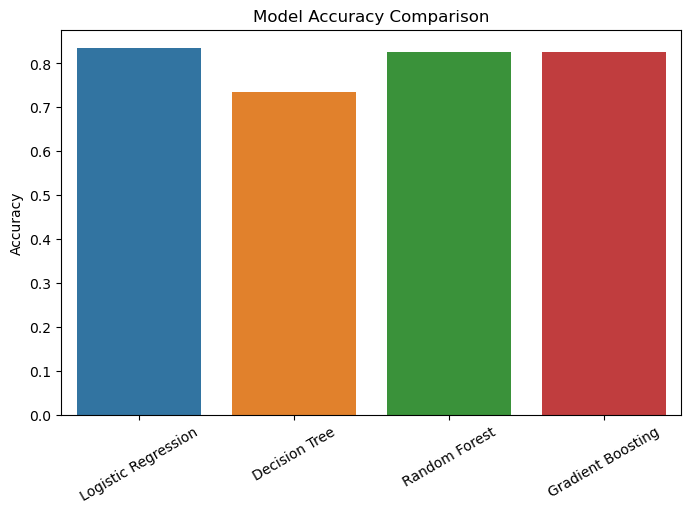

In [11]:
models = ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"]

scores = [
accuracy_score(y_test, lr_pred),
accuracy_score(y_test, dt_pred),
accuracy_score(y_test, rf_pred),
accuracy_score(y_test, gb_pred)
]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=scores)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

# 9. Confusion Matrix

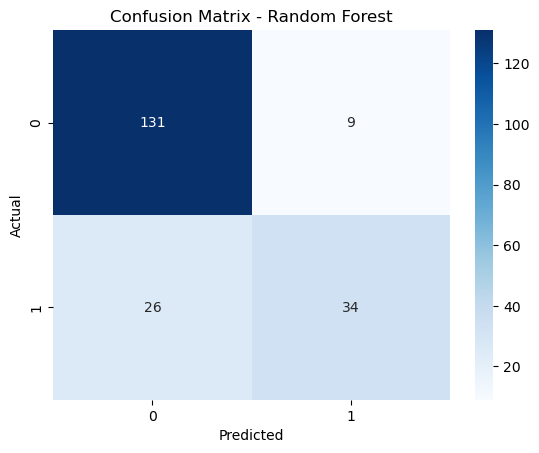

In [16]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# 10.Classification Report

In [17]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.94      0.88       140
           1       0.79      0.57      0.66        60

    accuracy                           0.82       200
   macro avg       0.81      0.75      0.77       200
weighted avg       0.82      0.82      0.82       200



# 11.ROC Curve

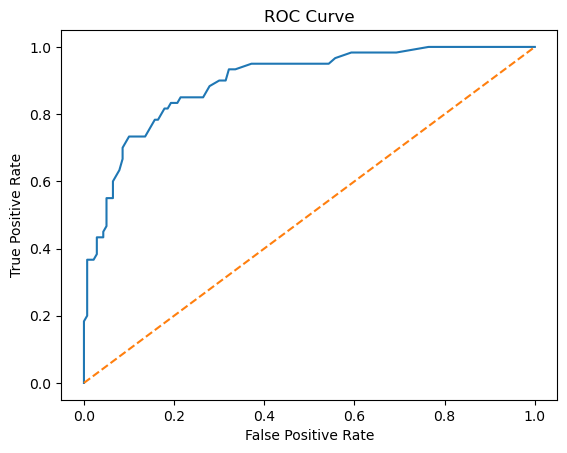

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score

prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, prob)

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

# Final Conclusion
## Conclusion

This project demonstrates how machine learning can be used to predict credit risk using financial data.

The models were evaluated using accuracy and classification metrics. Ensemble models such as Random Forest and Gradient Boosting showed strong performance.

Key insights:
• Credit score strongly influences creditworthiness  
• Late payments increase default risk  
• Debt-to-income ratio impacts repayment ability

This type of model can help financial institutions make better lending decisions.